<div hidden=True>
    author: Marco Angius
    company: TomorrowData srl
    mail: marco.angius@tomorrowdata.io
    notebook-version: nov20-2.1
</div>

# AI for the Industry Domain: Predicting Performance and Availability
### A case study with real production data 

This notebook is meant for showing one of the many possible applications of machine learning concerning the Industry domain. 

To be more specif we are going to predict two KPIs, **Availability** and **Performance** given some data from a production line machine. We would like to create two models for prediction each one of those KPIs.

## Alarms Dataset and Telemetry Dataset
For this case study real world data is used. Data is available only for the *bottleneck* machine of a production line. The datasets have been already processed in order to make the time discrete (slotted) into hours and remove some sensitive information.

Two datasets are provided, one for the alarms and one for the telemetry data of the *bottleneck* machine. 

### Alarms Dataset
This dataset contains alarms' information which has been aggregated hourly. 

The following attributes are available: 
- `timestamp`: timestamp value for the record; 
- `allarme_id`: ID of the alarm which uniquely identifies it;
- `allarme_bloccante`: if true, the alarm causes the machine to stop during while active;   
- `allarme_durata_media`: mean duration of the alarm;
- `allarme_tf_medio`: mean machine stopping time caused by the alarm; 
- `allarme_numero`: the number of times the alarm occurred; 

Only years, months, days and hours are specified for the *timestamp* column. A record with timestamp `2020-02-03 15:00:00` refers to an alarm occurred once or multiple times from the `15:00` and the `15:59` of that day;

### Telemetry Dataset
This dataset contains the telemetry (production, timings, etc...) data which has been aggregated hourly.

The following attributes are available: 
- `timestamp`: timestamp value for the record;
- `tel_pezzi_prodotti`: aggregated produced units;
- `tel_tempo_attivo`: aggregated active time;
- `tel_tempo_fermo`: aggregated down time;
- `tel_velocità_nominale`: nominal velocity of the machine;
- `disponibilità`: hourly computed KPI;
- `efficienza`: hourly computed KPI; 

Only years, months, days and hours are specified for the *timestamp* column. A record with timestamp `2020-02-03 15:00:00` refers to telemetry data acquired from the `15:00` and the `15:59` of that day and aggregated for discretization purposes;

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [3]:
alarms_df = pd.read_csv('./datasets/machine_production_case_study/dataset_allarmi.csv.zip')
tels_df = pd.read_csv('./datasets/machine_production_case_study/dataset_telemtria.csv.zip')

Alarms Dataframe

In [4]:
alarms_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8875 entries, 0 to 8874
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             8875 non-null   object 
 1   allarme_id            8875 non-null   int64  
 2   allarme_bloccante     3811 non-null   object 
 3   allarme_durata_media  8875 non-null   float64
 4   allarme_tf_medio      8875 non-null   float64
 5   allarme_numero        8875 non-null   int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 416.1+ KB


Telemetry Dataset

In [5]:
tels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   timestamp              736 non-null    object 
 1   tel_pezzi_prodotti     736 non-null    float64
 2   tel_tempo_attivo       736 non-null    int64  
 3   tel_tempo_fermo        736 non-null    int64  
 4   tel_velocità_nominale  736 non-null    float64
 5   disponibilità          736 non-null    float64
 6   efficienza             682 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 40.4+ KB


# KPIs: Domain Dependent Knowledge

## Availability (Disponibilità)
Given the following: 
- *ActiveTime*: time when the machine is producing units (seconds)
- *DownTime*: time when the machine is not producing but was scheduled to do it (seconds)

The sum of $Active Time + Down Time$ gives the *planned production time*

This Key Performance Indicator is defined as follows: 


$$ Availability = \dfrac{ActiveTime}{ActiveTime + DownTime}$$

<hr>

## Performance (Efficienza)
- *ActiveTime*: time when the machine is producing units (seconds)
- *ProducedUnits*: produced units in the time interval (units)
- *NominalVelocity*: the set nominal velocity (units/seconds)for the machine

This Key Performance Indicator is defined as follows: 


$$ Performance = \dfrac{ProducedUnits \div ActiveTime}{NominalVelocity} $$

# EDA
First we look at the available data in order to get familiar with it and observe possible patterns.

## Telemetry
Explore telemetry data: 

In [6]:
tels_df.sample(5)

,timestamp,tel_pezzi_prodotti,tel_tempo_attivo,tel_tempo_fermo,tel_velocità_nominale,disponibilità,efficienza
459,2020-05-15 22:00:00,1383.968176,3046,554,0.46462,0.8461,0.9779
195,2020-04-28 04:00:00,0.000000,0,3597,0.46462,0.0000,NaN
653,2020-06-01 06:00:00,0.000000,0,3600,0.46462,0.0000,NaN
489,2020-05-19 17:00:00,1330.994764,2995,605,0.46462,0.8319,0.9565
75,2020-04-15 09:00:00,816.886250,1752,1848,0.46462,0.4867,1.0035


In [7]:
tels_df = tels_df.set_index('timestamp').sort_index()

In [9]:
tels_df.head(5)

,tel_pezzi_prodotti,tel_tempo_attivo,tel_tempo_fermo,tel_velocità_nominale,disponibilità,efficienza
timestamp,,,,,,
2020-04-09 04:00:00,703.693957,1618,1980,0.46462,0.4497,0.9361
2020-04-09 05:00:00,1320.959660,2975,630,0.46462,0.8252,0.9557
2020-04-09 06:00:00,886.029560,2031,1569,0.46462,0.5642,0.9389
2020-04-09 07:00:00,542.546569,1263,2337,0.46462,0.3508,0.9246
2020-04-09 08:00:00,948.481177,2154,1446,0.46462,0.5983,0.9477


### Missing Values

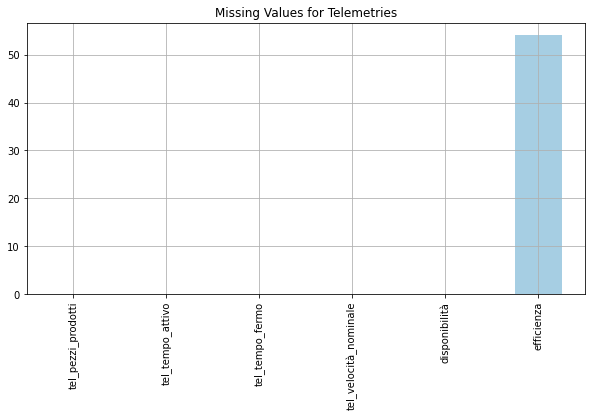

In [10]:
# print missing values
f = plt.figure(figsize=(10, 5))
ax = f.add_subplot()
tels_df.isna().sum().plot(kind='bar', cmap=plt.cm.Paired, ax=ax)
_ = ax.grid()
_ = ax.set_title('Missing Values for Telemetries')

In [11]:
tels_df.isna().sum()

tel_pezzi_prodotti        0
tel_tempo_attivo          0
tel_tempo_fermo           0
tel_velocità_nominale     0
disponibilità             0
efficienza               54
dtype: int64

In [12]:
# it is possible to have missing values for the performance when there is no active time 
# this is a zero by zero division so the result is NaN

In [13]:
tels_df[tels_df.efficienza.isna()].head(5)

,tel_pezzi_prodotti,tel_tempo_attivo,tel_tempo_fermo,tel_velocità_nominale,disponibilità,efficienza
timestamp,,,,,,
2020-04-22 07:00:00,0.0,0,3600,0.46462,0.0,NaN
2020-04-22 17:00:00,0.0,0,3600,0.46462,0.0,NaN
2020-04-27 05:00:00,0.0,0,3600,0.46462,0.0,NaN
2020-04-27 06:00:00,0.0,0,3605,0.46462,0.0,NaN
2020-04-27 07:00:00,0.0,0,3605,0.46462,0.0,NaN


In [14]:
# check if our intuition is correct
assert tels_df[tels_df.efficienza.isna()].query('tel_tempo_attivo > 0').size == 0

In [15]:
# it is possible to set the performance to 0 when this happens
tels_df.efficienza = tels_df.efficienza.fillna(0)

In [16]:
# verify all missing values are fixed
assert tels_df.isna().sum().sum() == 0

### Attributes statistics

In [17]:
tels_df.describe().T

,count,mean,std,min,25%,50%,75%,max
tel_pezzi_prodotti,736.0,805.009467,5.624146e+02,0.00000,437.717369,850.900061,1168.733981,7178.516732
tel_tempo_attivo,736.0,1837.868207,1.253954e+03,0.00000,1022.250000,1984.000000,2647.000000,15895.000000
tel_tempo_fermo,736.0,1859.578804,1.375549e+03,35.00000,953.750000,1622.500000,2553.250000,17972.000000
tel_velocità_nominale,736.0,0.464620,1.121420e-15,0.46462,0.464620,0.464620,0.464620,0.464620
disponibilità,736.0,0.499464,2.834506e-01,0.00000,0.286775,0.549300,0.735075,0.990300
efficienza,736.0,0.843583,2.730231e-01,0.00000,0.879150,0.938400,0.964250,1.021000


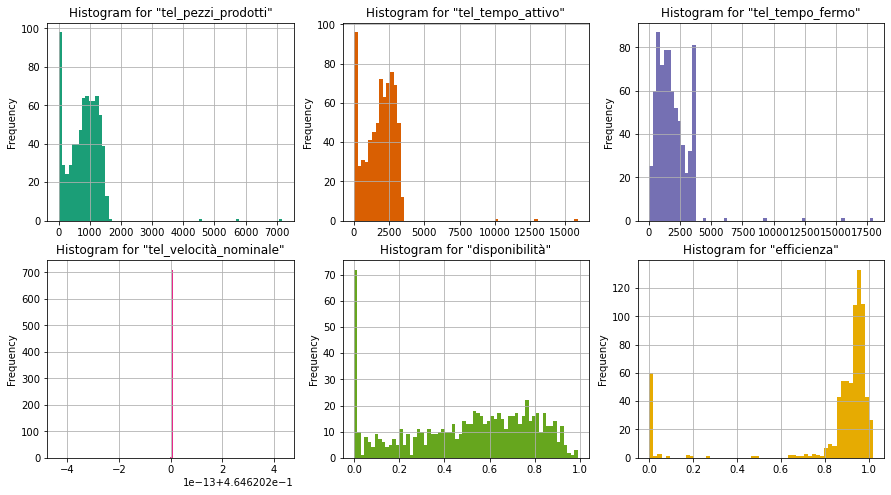

In [18]:
# print historgrams for each feature and the two kpi targets
f, axs = plt.subplots(2, 3, figsize=(15, 8))
for i, pack in enumerate(zip(axs.flat, tels_df.columns)):
    ax, col = pack
    vc = tels_df[col].value_counts().shape[0] 
    bins_ = int(vc/10) if vc > 100 else 10
    tels_df[col].plot(kind='hist', bins=bins_, color=plt.cm.Dark2.colors[i], ax=ax)
    _ = ax.grid()
    _ = ax.set_title(f'Histogram for "{col}"')

 ### Correlations

In [19]:
tels_df.corr()

,tel_pezzi_prodotti,tel_tempo_attivo,tel_tempo_fermo,tel_velocità_nominale,disponibilità,efficienza
tel_pezzi_prodotti,1.000000,0.997711,-0.436131,0.001431,0.820835,0.531443
tel_tempo_attivo,0.997711,1.000000,-0.442004,0.003631,0.826837,0.532978
tel_tempo_fermo,-0.436131,-0.442004,1.000000,-0.092676,-0.776536,-0.466080
tel_velocità_nominale,0.001431,0.003631,-0.092676,1.000000,0.017123,-0.004403
disponibilità,0.820835,0.826837,-0.776536,0.017123,1.000000,0.636468
efficienza,0.531443,0.532978,-0.466080,-0.004403,0.636468,1.000000


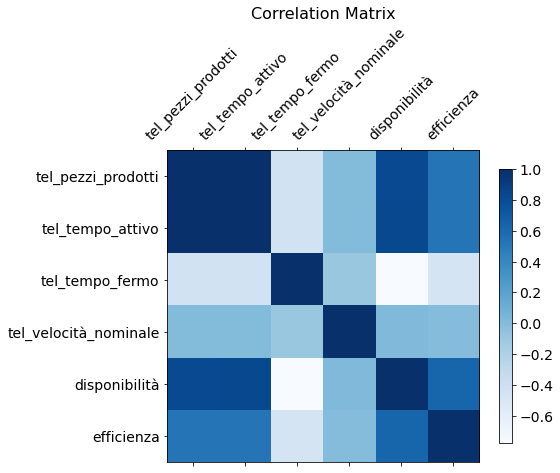

In [20]:
# plot correlation matrix
f = plt.figure(figsize=(7, 7))
plt.matshow(tels_df.corr(), cmap=plt.cm.Blues, fignum=f.number)
plt.xticks(range(tels_df.shape[1]), tels_df.columns, fontsize=14, rotation=45)
plt.yticks(range(tels_df.shape[1]), tels_df.columns, fontsize=14)
cb = plt.colorbar(shrink=0.7)
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16);

In [21]:
# it is possible to drop `tel_velocità_nominale`
tels_df = tels_df.drop(columns=['tel_velocità_nominale'])

## Plot some data

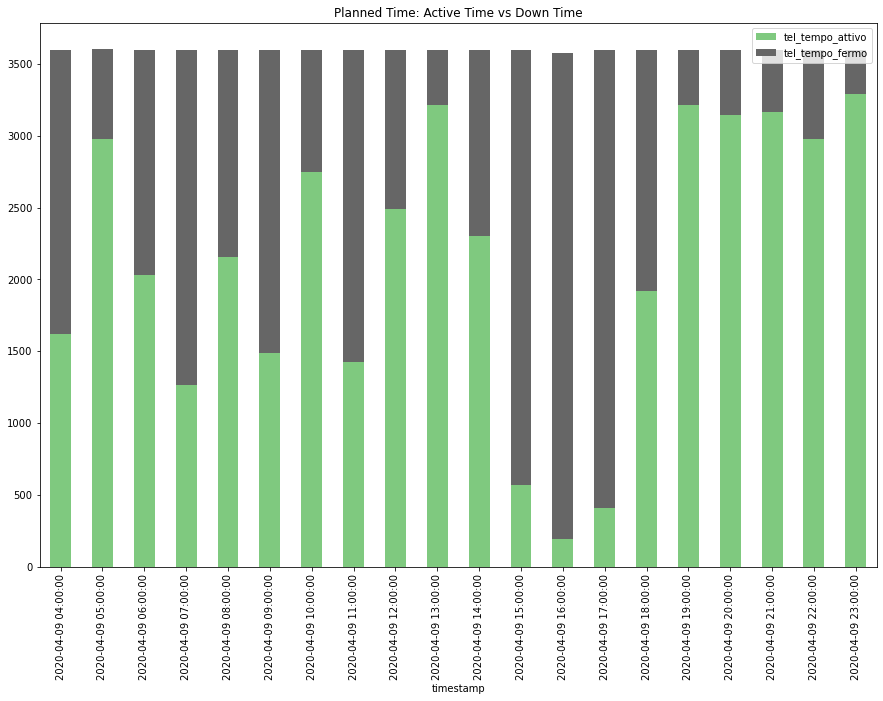

In [22]:
# plot active time and down time stacked bar
f = plt.figure(figsize=(15, 10))
ax = f.add_subplot()
tels_df['2020-04-09':'2020-04-10'][['tel_tempo_attivo', 'tel_tempo_fermo']]\
    .plot(kind='bar', stacked=True, cmap=plt.cm.Accent, ax=ax)
_ = ax.set_title('Planned Time: Active Time vs Down Time')

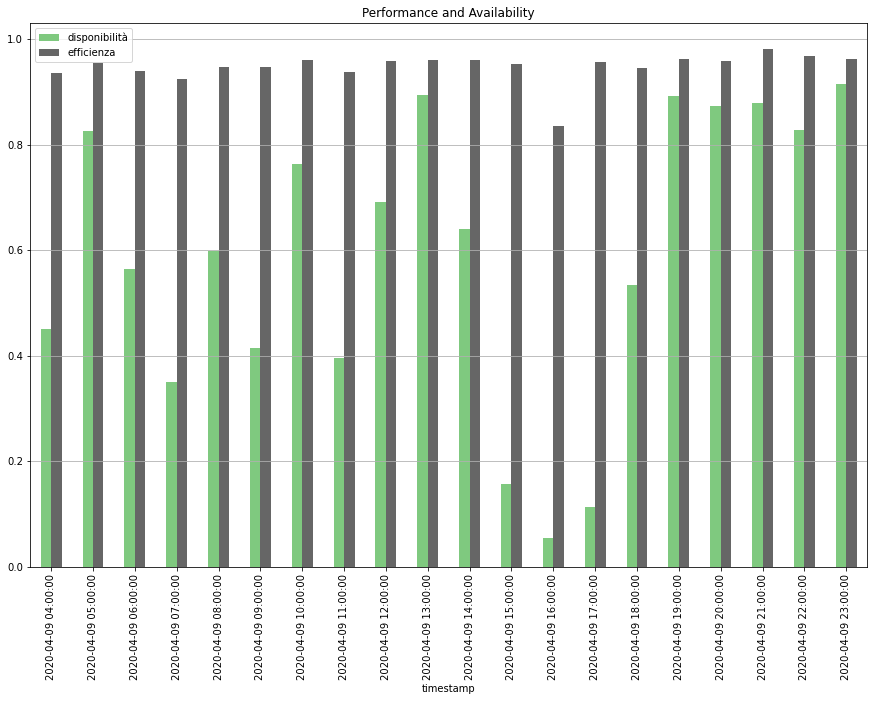

In [23]:
# plot availability and performance
f = plt.figure(figsize=(15, 10))
ax = f.add_subplot()
tels_df['2020-04-09':'2020-04-10'][['disponibilità', 'efficienza']]\
    .plot(kind='bar', cmap=plt.cm.Accent, ax=ax)
_ = ax.grid(axis='y')
_ = ax.set_title('Performance and Availability')

## Alarms
Explore Alarms data:

In [24]:
alarms_df.sample(5)

,timestamp,allarme_id,allarme_bloccante,allarme_durata_media,allarme_tf_medio,allarme_numero
1461,2020-04-20 17:00:00,0,NaN,215.285714,-1.0,14
2278,2020-04-28 05:00:00,110,NaN,936.666667,-1.0,3
7405,2020-05-27 22:00:00,11,NaN,1717.000000,-1.0,1
4381,2020-05-09 10:00:00,2,NaN,52.750000,-1.0,4
3061,2020-05-01 23:00:00,4,NaN,89.250000,-1.0,4


In [25]:
alarms_df = alarms_df.set_index('timestamp').sort_index()

In [26]:
alarms_df.head(5)

,allarme_id,allarme_bloccante,allarme_durata_media,allarme_tf_medio,allarme_numero
timestamp,,,,,
2020-04-09 04:00:00,0,NaN,93.875,-1.0,16
2020-04-09 04:00:00,4,NaN,22.000,-1.0,2
2020-04-09 04:00:00,11,NaN,916.000,-1.0,1
2020-04-09 04:00:00,12,NaN,916.000,-1.0,1
2020-04-09 04:00:00,13,NaN,916.000,-1.0,1


### Missing Values

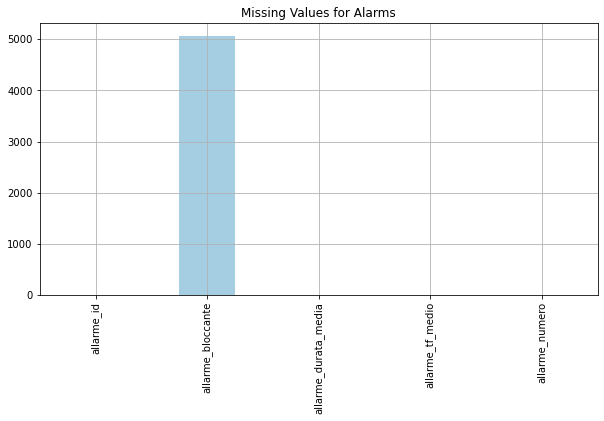

In [27]:
# plot missing values
f = plt.figure(figsize=(10, 5))
ax = f.add_subplot()
alarms_df.isna().sum().plot(kind='bar', cmap=plt.cm.Paired, ax=ax)
_ = ax.grid()
_ = ax.set_title('Missing Values for Alarms')

In [28]:
alarms_df[alarms_df.allarme_bloccante.isna()].head(5)

,allarme_id,allarme_bloccante,allarme_durata_media,allarme_tf_medio,allarme_numero
timestamp,,,,,
2020-04-09 04:00:00,0,NaN,93.875,-1.0,16
2020-04-09 04:00:00,4,NaN,22.000,-1.0,2
2020-04-09 04:00:00,11,NaN,916.000,-1.0,1
2020-04-09 04:00:00,12,NaN,916.000,-1.0,1
2020-04-09 04:00:00,13,NaN,916.000,-1.0,1


In [29]:
alarms_df.allarme_bloccante.value_counts()

True    3811
Name: allarme_bloccante, dtype: int64

In [30]:
# fill missing values with false 
alarms_df.allarme_bloccante = alarms_df.allarme_bloccante.fillna(False)

In [31]:
# verify all missing values are fixed
assert alarms_df.isna().sum().sum() == 0

In [33]:
alarms_df.sort_index().head(10)

,allarme_id,allarme_bloccante,allarme_durata_media,allarme_tf_medio,allarme_numero
timestamp,,,,,
2020-04-09 04:00:00,0,False,93.875,-1.0,16
2020-04-09 04:00:00,4,False,22.000,-1.0,2
2020-04-09 04:00:00,11,False,916.000,-1.0,1
2020-04-09 04:00:00,12,False,916.000,-1.0,1
2020-04-09 04:00:00,13,False,916.000,-1.0,1
2020-04-09 04:00:00,14,False,916.000,-1.0,1
2020-04-09 04:00:00,40,False,916.000,-1.0,1
2020-04-09 04:00:00,41,False,916.000,-1.0,1
2020-04-09 04:00:00,42,False,916.000,-1.0,1


### Attributes statistics

In [34]:
alarms_df.describe().T

,count,mean,std,min,25%,50%,75%,max
allarme_id,8875.0,65.608225,51.517089,0.0,4.0,67.0,107.0,157.0
allarme_durata_media,8875.0,304.626471,2113.198583,1.0,12.0,40.5,136.0,120500.0
allarme_tf_medio,8875.0,118.976054,796.754366,-1.0,-1.0,-1.0,24.5,30029.0
allarme_numero,8875.0,3.434592,5.682958,1.0,1.0,1.0,3.0,88.0


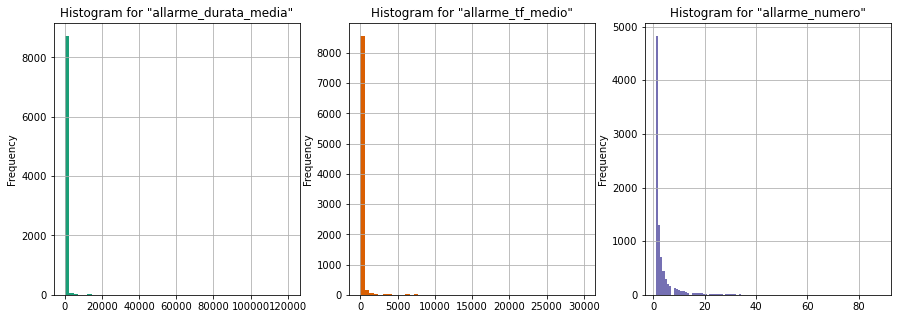

In [35]:
f, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, pack in enumerate(zip(axs.flat, 
                             alarms_df.drop(columns=['allarme_id', 'allarme_bloccante']).columns,
                             (50, 50, 100))):
    ax, col, bin_ = pack
    alarms_df[col].plot(kind='hist', bins=bin_, color=plt.cm.Dark2.colors[i], ax=ax)
    _ = ax.grid()
    _ = ax.set_title(f'Histogram for "{col}"')

## Checking number of alarms
Some alarms may present a binary outcome for the `allarme_bloccante` column. That is, in some circumstances they may be blocking for the bottleneck machine while in other they might be not. We are going to map this bivalent realization of such alarms.

In [36]:
print("Number of unique alarms: ", alarms_df.allarme_id.unique().size)

Number of unique alarms:  115


In [37]:
# groupby and count each occurence of alarms given the two possible blocking states
tmp = alarms_df.filter(items=['allarme_id', 'allarme_bloccante']) \
    .reset_index(drop=True)
tmp['total_alarms'] = np.ones_like(tmp.allarme_id.values)
alarms_state_count = tmp.groupby(['allarme_id', 'allarme_bloccante']).sum()

In [38]:
alarms_state_count = alarms_state_count.reset_index()
alarms_state_count['id_'] = alarms_state_count \
    .filter(items=['allarme_id', 'allarme_bloccante']) \
    .apply(lambda x: str(x[0]) + '_b' if x[1] else str(x[0]) + '_n', raw=True, axis=1)
alarms_state_count = alarms_state_count.sort_values('total_alarms', ascending=False)

In [39]:
# top 10 alarms
alarms_state_count[:10]

,allarme_id,allarme_bloccante,total_alarms,id_
0,0,False,701,0_n
4,4,False,579,4_n
118,110,False,575,110_n
117,107,True,527,107_b
2,2,False,517,2_n
161,149,False,426,149_n
5,4,True,350,4_b
78,67,True,293,67_b
116,107,False,204,107_n
111,102,True,184,102_b


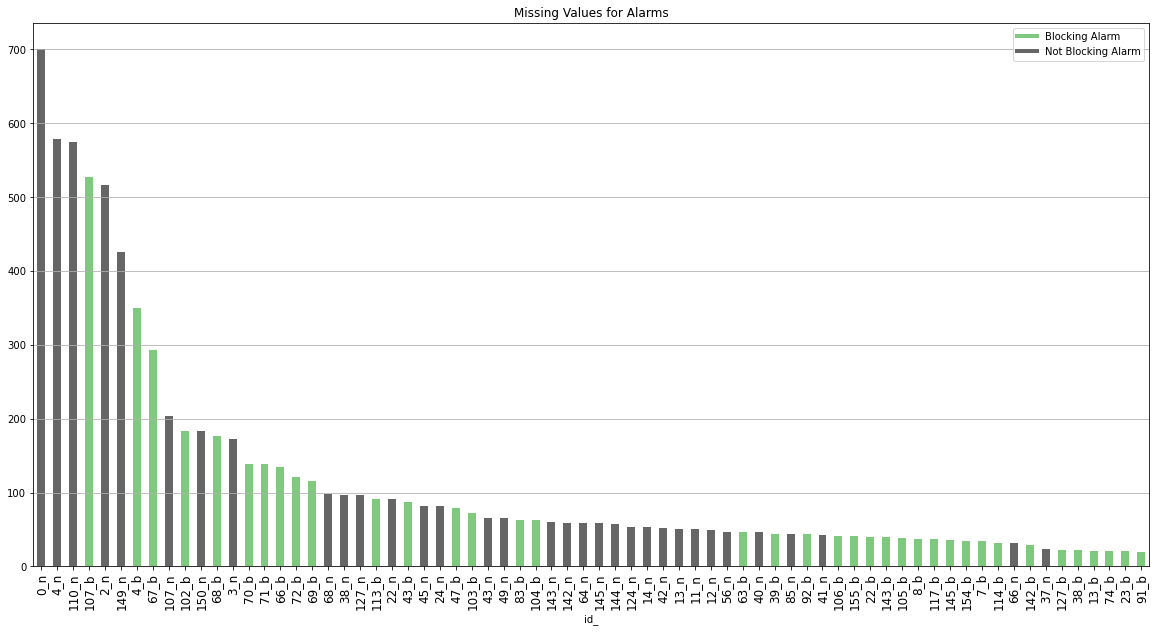

In [40]:
# prepare colors for bars
c1, c2 = plt.cm.Accent.colors[0], plt.cm.Accent.colors[-1]
color_bars = [c1 if 'b' in str(id_) else c2 for id_ in list(alarms_state_count.id_.values)]

# plot the top 70 alarms
f = plt.figure(figsize=(20, 10))
custom_lines = [Line2D([0], [0], color=c1, lw=4), Line2D([0], [0], color=c2, lw=4)]
ax = f.add_subplot()
alarms_state_count.iloc[:70].plot(x='id_', y='total_alarms', kind='bar', color=color_bars, ax=ax)
_ = ax.legend(custom_lines, ['Blocking Alarm', 'Not Blocking Alarm'])
_ = ax.grid(axis='y')
_ = ax.set_title('Missing Values for Alarms')
_ = ax.tick_params(axis='x', labelsize=12)

In [42]:
alarms_state_count.id_.count()

173

In [41]:
print("Total number of blocking alarms: ", sum(['b' in id_ for id_ in alarms_state_count.id_.values]))

Total number of blocking alarms:  97


In [43]:
# use quantiles for checking frequency distribution
alarms_state_count.query('allarme_bloccante == True') \
    .describe([0.5, 0.75, 0.80, 0.9, 0.95]) \
    .drop(columns=['allarme_id']) \
    .T

,count,mean,std,min,50%,75%,80%,90%,95%,max
total_alarms,97.0,39.28866,75.806491,1.0,15.0,37.0,41.0,101.0,146.4,527.0


In [50]:
# use the max total_alarms in order to estimate the frequrncy of the selected most blocking
top_blocking_alarms = alarms_state_count.query('allarme_bloccante == True and total_alarms > 41').copy()
top_blocking_alarms['frequency'] =  top_blocking_alarms.total_alarms / alarms_state_count.total_alarms.max()
top_blocking_alarms

,allarme_id,allarme_bloccante,total_alarms,id_,frequency
117,107,True,527,107_b,0.751783
5,4,True,350,4_b,0.499287
78,67,True,293,67_b,0.417974
111,102,True,184,102_b,0.262482
80,68,True,176,68_b,0.251070
82,70,True,139,70_b,0.198288
83,71,True,138,71_b,0.196862
76,66,True,134,66_b,0.191155
84,72,True,121,72_b,0.172611
81,69,True,116,69_b,0.165478


In [45]:
# filter out only most blocking alarms from the original dataset
most_blocking_ids = list(top_blocking_alarms.allarme_id.values)
alarms_df_mb = alarms_df[[id_ in most_blocking_ids for id_ in alarms_df.allarme_id]]
alarms_df_mb = alarms_df_mb.query('allarme_bloccante == True')

In [46]:
alarms_df_mb

,allarme_id,allarme_bloccante,allarme_durata_media,allarme_tf_medio,allarme_numero
timestamp,,,,,
2020-04-09 04:00:00,70,True,1.50,2.0,2
2020-04-09 04:00:00,71,True,1.00,2.0,1
2020-04-09 04:00:00,72,True,1.00,2.0,1
2020-04-09 04:00:00,92,True,11.50,12.0,4
2020-04-09 04:00:00,102,True,2880.00,2907.0,1
...,...,...,...,...,...
2020-06-08 18:00:00,4,True,226.00,228.0,1
2020-06-08 18:00:00,66,True,9.00,9.0,1
2020-06-08 18:00:00,67,True,13.75,14.0,4


In [47]:
alarms_df_mb.describe([0.25, 0.5, 0.75, 0.85, 0.9, 0.95, 0.98, 0.99])

,allarme_id,allarme_durata_media,allarme_tf_medio,allarme_numero
count,2767.000000,2767.000000,2767.000000,2767.000000
mean,71.861222,151.532865,219.648343,2.368269
std,32.559566,651.937483,893.340969,3.162834
min,4.000000,1.000000,1.000000,1.000000
25%,66.000000,9.000000,13.291667,1.000000
50%,70.000000,27.000000,34.000000,1.000000
75%,103.000000,76.944444,101.000000,3.000000
85%,107.000000,157.000000,208.025000,4.000000
90%,107.000000,249.800000,364.700000,5.000000
95%,107.000000,677.850000,856.700000,7.000000


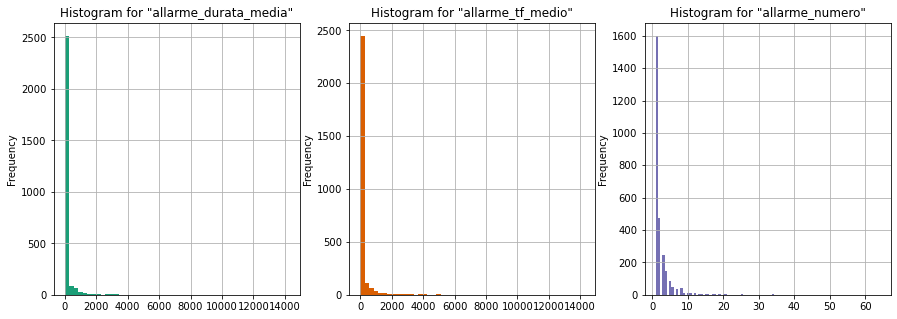

In [48]:
f, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, pack in enumerate(zip(axs.flat, 
                             alarms_df_mb.drop(columns=['allarme_id', 'allarme_bloccante']).columns,
                             (50, 50, 100))):
    ax, col, bin_ = pack
    alarms_df_mb[col].plot(kind='hist', bins=bin_, color=plt.cm.Dark2.colors[i], ax=ax)
    _ = ax.grid()
    _ = ax.set_title(f'Histogram for "{col}"')

# Pre-Processing

## Telemetry

In [52]:
# create a copy of the original
tels_df_pp = tels_df.copy()

### Remove Outliers
The following features are showing outliers: 
- `tel_pezzi_prodotti`
- `tel_tempo_attivo`
- `tel_tempo_fermo`

In [53]:
tels_quantiles = tels_df_pp.iloc[:, :3].describe([0.8, 0.9, 0.95, 0.98, 0.99]).T
tels_quantiles

,count,mean,std,min,50%,80%,90%,95%,98%,99%,max
tel_pezzi_prodotti,736.0,805.009467,562.414645,0.0,850.900061,1226.16708,1344.935628,1438.613166,1510.153838,1547.205578,7178.516732
tel_tempo_attivo,736.0,1837.868207,1253.953791,0.0,1984.000000,2780.00000,3045.500000,3219.000000,3329.800000,3425.900000,15895.000000
tel_tempo_fermo,736.0,1859.578804,1375.549097,35.0,1622.500000,2840.00000,3547.000000,3600.000000,3600.000000,3606.300000,17972.000000


In [54]:
# create the query for removing the outliers
q = " and ".join(["{} <= {}".format(name, np.round(th, 3)) for name, th 
                  in zip(tels_quantiles.index, tels_quantiles['99%'])])

In [55]:
q

'tel_pezzi_prodotti <= 1547.206 and tel_tempo_attivo <= 3425.9 and tel_tempo_fermo <= 3606.3'

In [56]:
tels_df_pp = tels_df_pp.query(q)

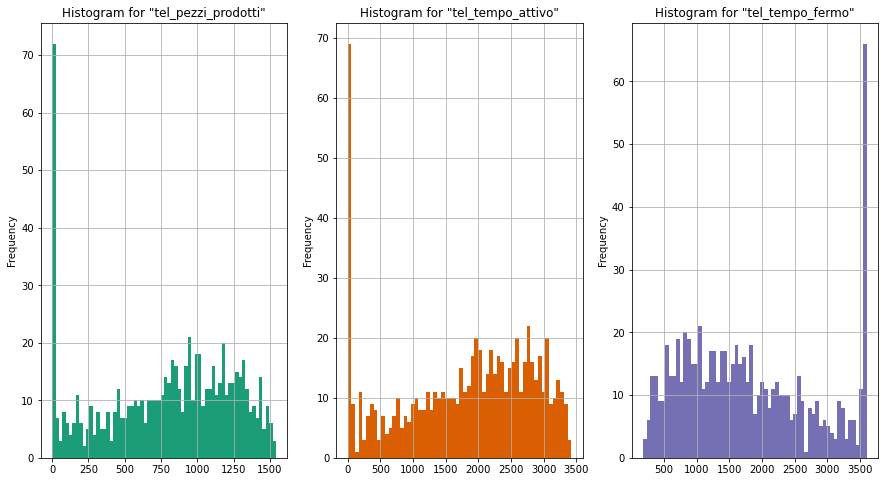

In [57]:
# verifica rimozione outliers
f, axs = plt.subplots(1, 3, figsize=(15, 8))
for i, pack in enumerate(zip(axs.flat, tels_df_pp.columns)):
    ax, col = pack
    vc = tels_df_pp[col].value_counts().shape[0] 
    bins_ = int(vc/10) if vc > 100 else 10
    tels_df_pp[col].plot(kind='hist', bins=bins_, color=plt.cm.Dark2.colors[i], ax=ax)
    _ = ax.grid()
    _ = ax.set_title(f'Histogram for "{col}"')

### Removing Collinearity
The `tel_tempo_attivo` and `tel_tempo_fermo` are collinear features. They are correlated with each other, thus one of them must be removed.

In [59]:
tels_df_pp.iloc[:, :3].corr()

,tel_pezzi_prodotti,tel_tempo_attivo,tel_tempo_fermo
tel_pezzi_prodotti,1.000000,0.996526,-0.984697
tel_tempo_attivo,0.996526,1.000000,-0.988154
tel_tempo_fermo,-0.984697,-0.988154,1.000000


In [60]:
tels_df_pp = tels_df_pp.drop(columns=['tel_tempo_fermo'])

In [61]:
tels_df_pp.head(5)

,tel_pezzi_prodotti,tel_tempo_attivo,disponibilità,efficienza
timestamp,,,,
2020-04-09 04:00:00,703.693957,1618,0.4497,0.9361
2020-04-09 05:00:00,1320.959660,2975,0.8252,0.9557
2020-04-09 06:00:00,886.029560,2031,0.5642,0.9389
2020-04-09 07:00:00,542.546569,1263,0.3508,0.9246
2020-04-09 08:00:00,948.481177,2154,0.5983,0.9477


## Alarms

In [62]:
# create a copy of the original
alarms_df_pp = alarms_df_mb.copy()

### Removing Outliers
The following features are showing outliers: 
- `allarme_durata_media`
- `allarme_tf_medio`
- `allarme_numero`

In [63]:
alarm_quantiles = alarms_df_pp.iloc[:, 2:].describe([0.8, 0.9, 0.95, 0.98, 0.99, 0.999]).T
alarm_quantiles

,count,mean,std,min,50%,80%,90%,95%,98%,99%,99.9%,max
allarme_durata_media,2767.0,151.532865,651.937483,1.0,27.0,106.000000,249.8,677.85,1342.36,1988.92,12510.628,14243.0
allarme_tf_medio,2767.0,219.648343,893.340969,1.0,34.0,142.370588,364.7,856.70,2013.28,3663.67,12857.978,14251.0
allarme_numero,2767.0,2.368269,3.162834,1.0,1.0,3.000000,5.0,7.00,11.00,16.00,34.000,64.0


In [64]:
# create the query for removing the outliers
q = " and ".join(["{} <= {}".format(name, np.round(th, 3)) for name, th 
                  in zip(alarm_quantiles.index, alarm_quantiles['98%'])])

In [65]:
alarms_df_pp = alarms_df_pp.query(q)

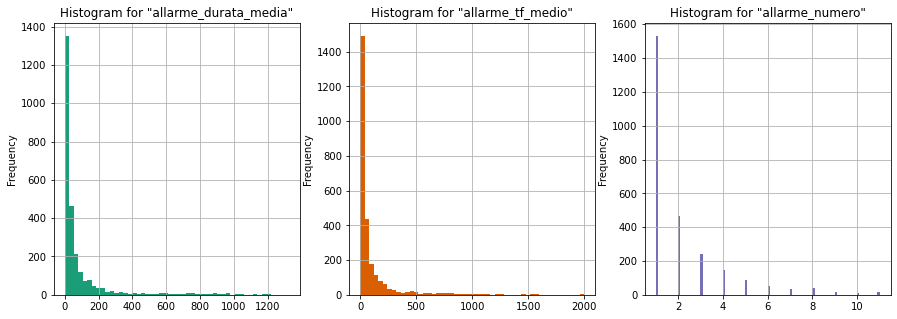

In [66]:
f, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, pack in enumerate(zip(axs.flat, 
                             alarms_df_pp.drop(columns=['allarme_id', 'allarme_bloccante']).columns,
                             (50, 50, 100))):
    ax, col, bin_ = pack
    alarms_df_pp[col].plot(kind='hist', bins=bin_, color=plt.cm.Dark2.colors[i], ax=ax)
    _ = ax.grid()
    _ = ax.set_title(f'Histogram for "{col}"')

### Removing Collinearity
The `allarme_durata_media` and `allarme_tf_medio` are collinear features. They are correlated with each other, thus one of them must be removed.

In [67]:
alarms_df_pp.iloc[:, 2:].corr()

,allarme_durata_media,allarme_tf_medio,allarme_numero
allarme_durata_media,1.000000,0.864832,-0.054797
allarme_tf_medio,0.864832,1.000000,-0.048742
allarme_numero,-0.054797,-0.048742,1.000000


In [68]:
# remve allarme_tf_medio
# remove also allarme_bloccante from the features 
alarms_df_pp = alarms_df_pp.drop(columns=['allarme_tf_medio', 'allarme_bloccante'])

In [69]:
alarms_df_pp.head(10)

,allarme_id,allarme_durata_media,allarme_numero
timestamp,,,
2020-04-09 04:00:00,70,1.5,2
2020-04-09 04:00:00,71,1.0,1
2020-04-09 04:00:00,72,1.0,1
2020-04-09 04:00:00,92,11.5,4
2020-04-09 04:00:00,104,5.0,1
2020-04-09 04:00:00,107,50.2,5
2020-04-09 05:00:00,68,243.0,1
2020-04-09 05:00:00,107,19.0,1
2020-04-09 05:00:00,113,49.0,1


In [70]:
def pivot_groupped_hourly(dfg): 
    new_df = {}
    for el in dfg.to_dict('records'): 
        new_df.update({
            'timestamp': el['timestamp'],
            f'alrm_{el["allarme_id"]}_durata': el["allarme_durata_media"], 
            f'alrm_{el["allarme_id"]}_numero': el["allarme_numero"]
        })
    return pd.DataFrame([new_df])

In [71]:
alarms_df_pp_pivoted =  alarms_df_pp.reset_index() \
    .groupby('timestamp', as_index=False, group_keys=False) \
    .apply(pivot_groupped_hourly) \
    .set_index('timestamp') \
    .sort_index() \
    .fillna(0)

In [73]:
alarms_df_pp_pivoted.head(5)

,alrm_70_durata,alrm_70_numero,alrm_71_durata,alrm_71_numero,alrm_72_durata,alrm_72_numero,alrm_92_durata,alrm_92_numero,alrm_104_durata,alrm_104_numero,...,alrm_102_durata,alrm_102_numero,alrm_63_durata,alrm_63_numero,alrm_47_durata,alrm_47_numero,alrm_39_durata,alrm_39_numero,alrm_43_durata,alrm_43_numero
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-04-09 04:00:00,1.5,2.0,1.0,1.0,1.0,1.0,11.5,4.0,5.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-04-09 05:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-04-09 06:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-04-09 07:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-04-09 08:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


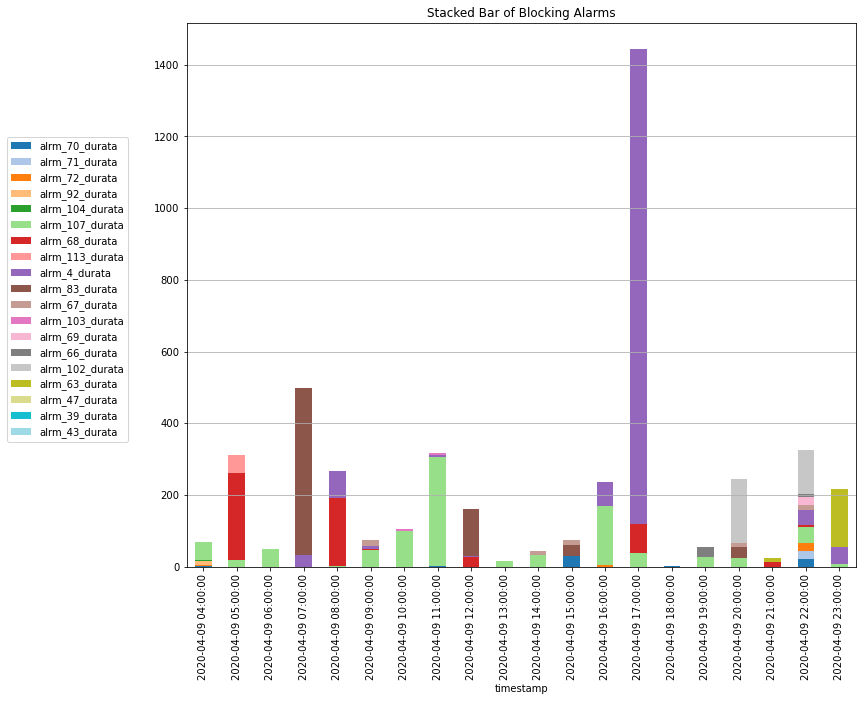

In [72]:
f = plt.figure(figsize=(12, 10))
ax = f.add_subplot()
alarms_df_pp_pivoted.iloc[:20].filter(regex='.*_durata').plot(kind='bar', stacked=True, 
                                                              cmap=plt.cm.tab20, ax=ax)
ax.legend(bbox_to_anchor=(-0.08, 0.8), ncol=1)
_ = ax.grid(axis='y')
_ = ax.set_title('Stacked Bar of Blocking Alarms')

# Setting up the ML Dataset
We would like to merge alarms to telemetry in order to use such information for predicting one or more KPIs.

In [78]:
# use join  (left in order to not lose telemetry records) given the already set index
dataset = tels_df_pp.join(alarms_df_pp_pivoted, how='left')

## Removing Null values due to join
It is possible that alarm information is missing for some records.

In [80]:
dataset = dataset.dropna()

In [81]:
assert dataset.isna().sum().sum() == 0

## Split X and y

In [83]:
# use regex negative lookhead to filter out the targets and the positive lookhead for getting the target
X = dataset.filter(regex='^(?!disponibilità|efficienza)')
y = dataset.filter(regex='(?=disponibilità|efficienza)')

## Scatterplots
### Availability

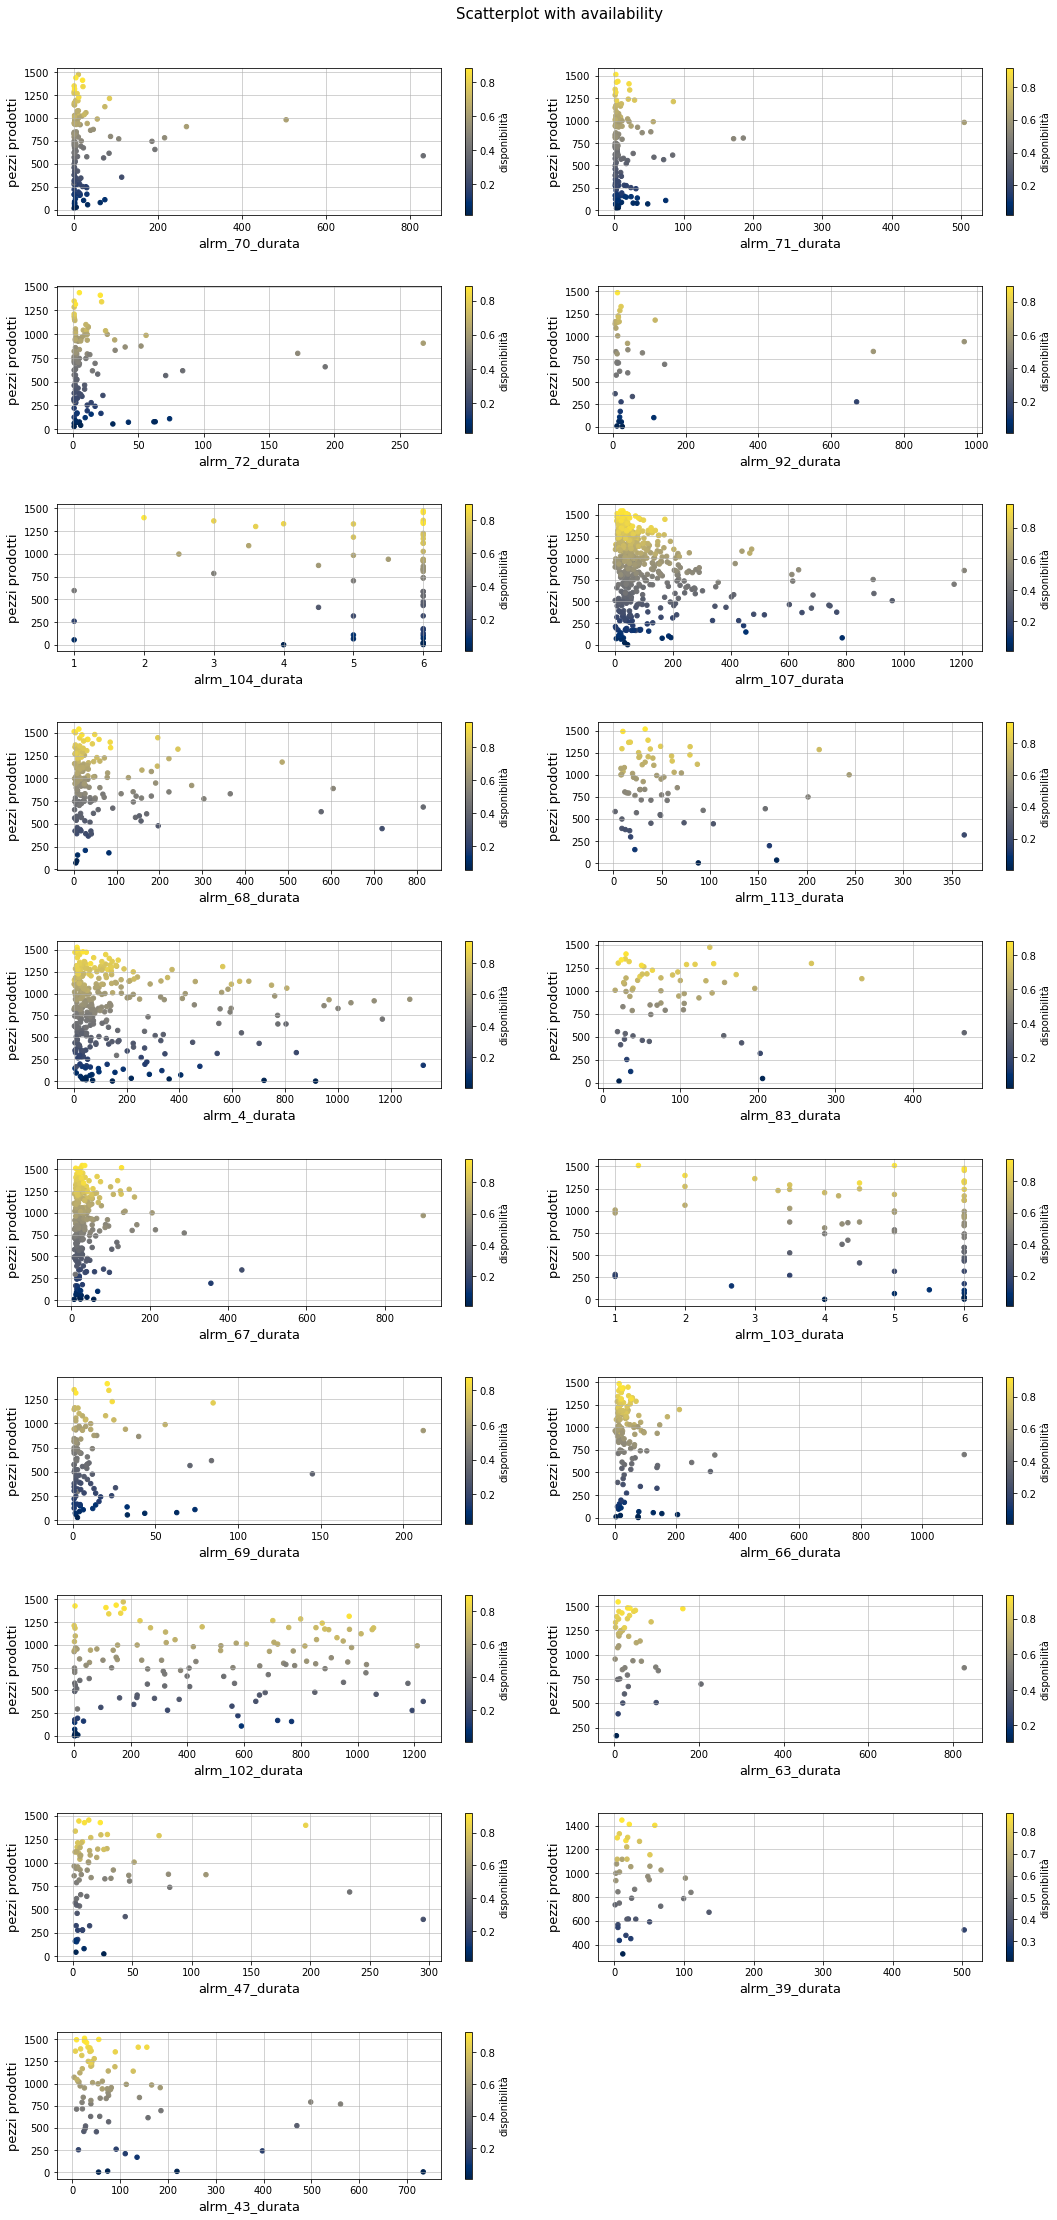

In [88]:
X_alar_d = X.query('tel_pezzi_prodotti > 0').filter(regex='alrm.*_durata')
numb_alarms = X_alar_d.shape[1]

f, axs = plt.subplots(int(np.ceil(numb_alarms/2)), 2, figsize=(15, 30))
f.tight_layout(pad=1.4, h_pad=5, w_pad=3)
plt.suptitle('Scatterplot with availability', y=1.02, size=15)
for i, pack in enumerate(zip(axs.flat, X_alar_d.columns)):
    ax, col = pack
    _ = dataset.query(f'tel_pezzi_prodotti > 0 and {col} > 0').plot(kind='scatter', 
                                                     x=col, 
                                                     y='tel_pezzi_prodotti', 
                                                     c='disponibilità', cmap=plt.cm.cividis,
                                                     ax=ax)
    _ = ax.grid(alpha=0.7)
    _ = ax.set_xlabel(col, size=13)
    _ = ax.set_ylabel('pezzi prodotti', size=13)
    
f.delaxes(axs[9, 1])

### Performance

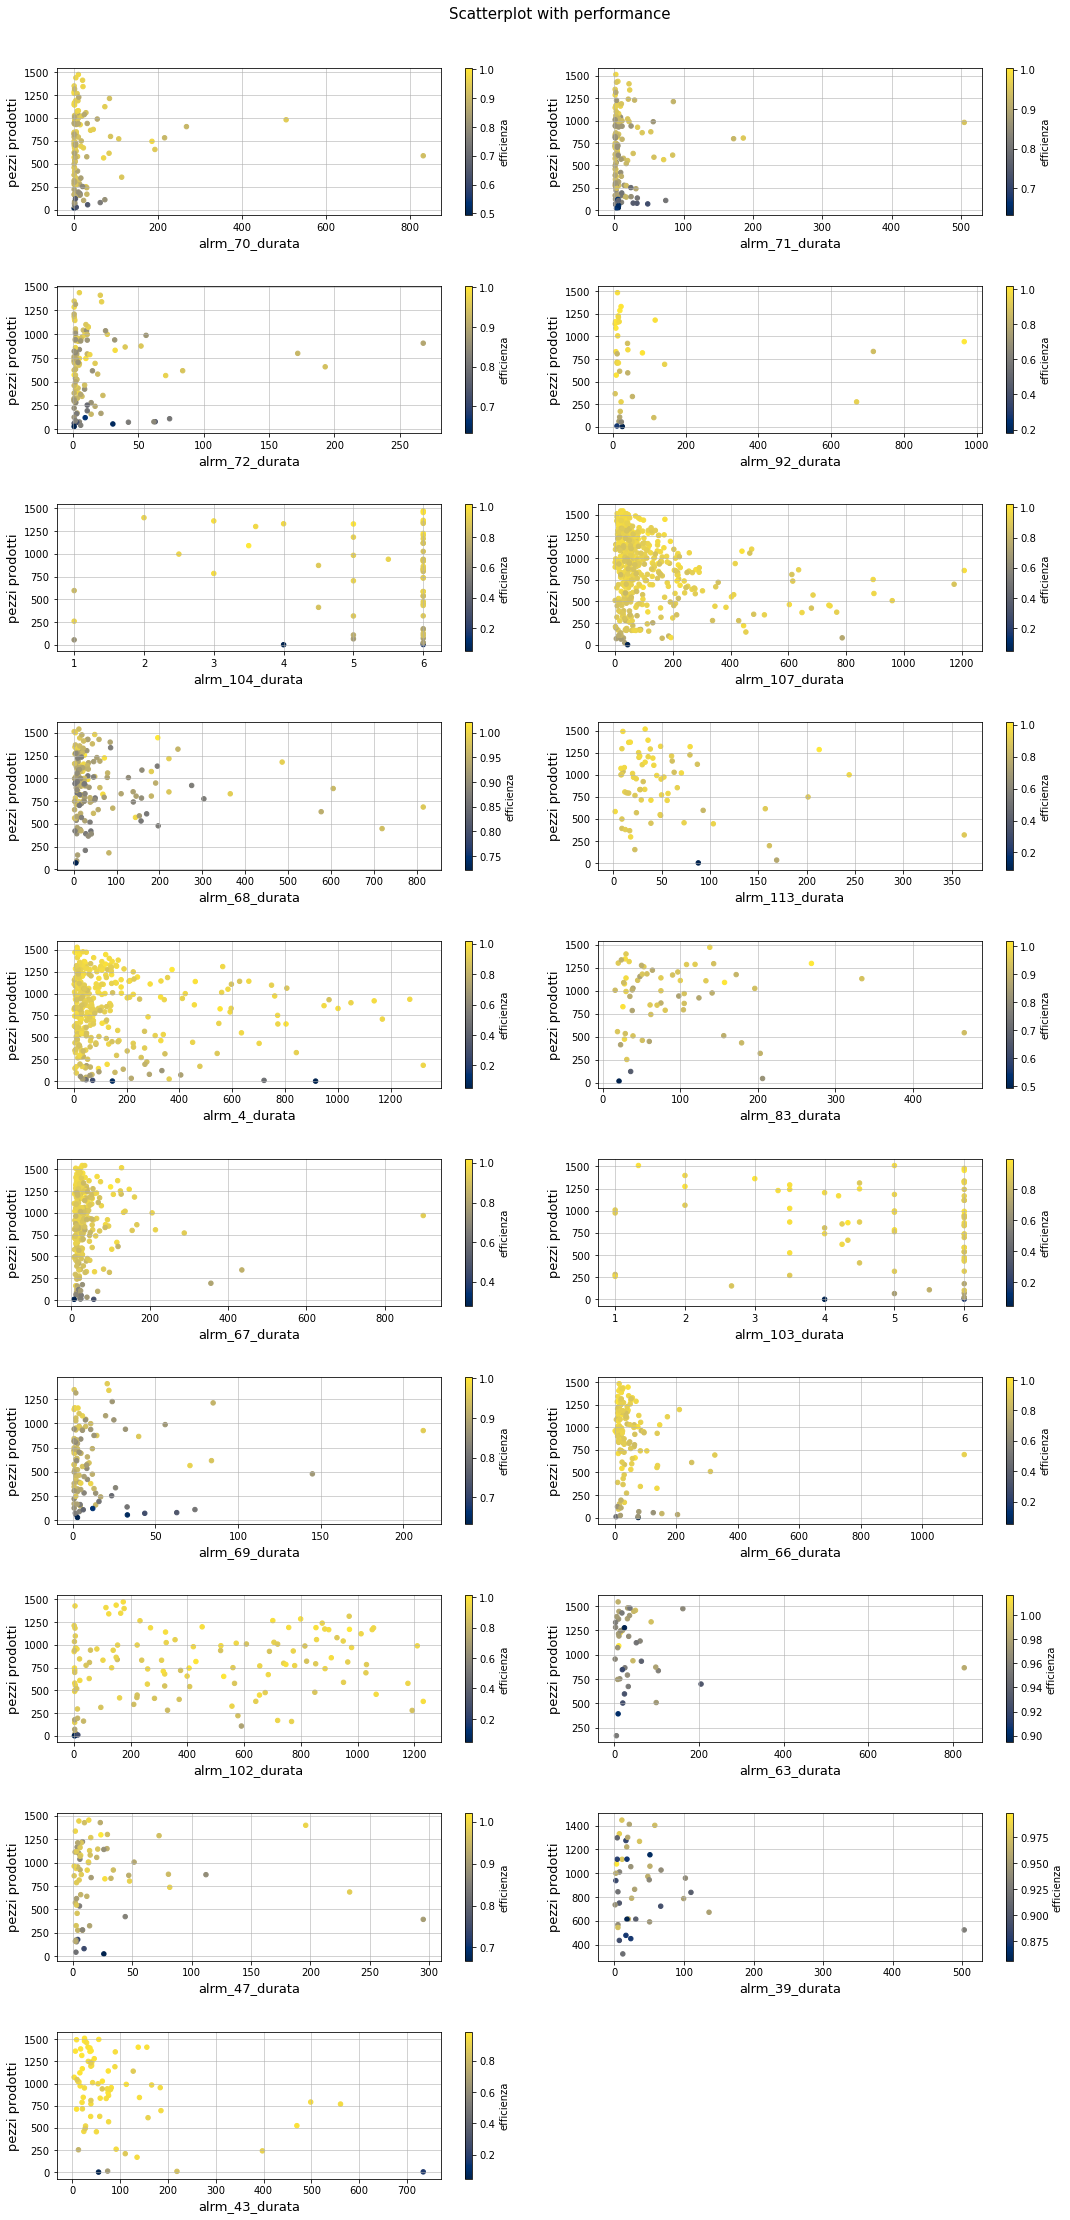

In [89]:
X_alar_d = X.query('tel_pezzi_prodotti > 0').filter(regex='alrm.*_durata')
numb_alarms = X_alar_d.shape[1]

f, axs = plt.subplots(int(np.ceil(numb_alarms/2)), 2, figsize=(15, 30))
f.tight_layout(pad=1.4, h_pad=5, w_pad=3)
plt.suptitle('Scatterplot with performance', y=1.02, size=15)
for i, pack in enumerate(zip(axs.flat, X_alar_d.columns)):
    ax, col = pack
    _ = dataset.query(f'tel_pezzi_prodotti > 0 and {col} > 0').plot(kind='scatter', 
                                                     x=col, 
                                                     y='tel_pezzi_prodotti', 
                                                     c='efficienza', cmap=plt.cm.cividis,
                                                     ax=ax)
    _ = ax.grid(alpha=0.7)
    _ = ax.set_xlabel(col, size=13)
    _ = ax.set_ylabel('pezzi prodotti', size=13)
    
f.delaxes(axs[9, 1])

## Training and Test

In [90]:
from sklearn.model_selection import train_test_split

In [92]:
# split train and test sets -> we will use the test for assing perfomances
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=90)

## Scaling

In [93]:
from sklearn.preprocessing import MinMaxScaler

In [94]:
mm_scaler = MinMaxScaler((0, 100))

In [95]:
mm_scaler.fit(X_train)

MinMaxScaler(feature_range=(0, 100))

In [96]:
X_train_mm = pd.DataFrame(mm_scaler.transform(X_train), columns=X_train.columns, index=X_train.index) 
X_test_mm = pd.DataFrame(mm_scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Model Selection 
## Predicting Availability

Our first goal is to predict the availability given the current features. For now we completely forget about the equation we have seen for the availability. 

In [110]:
y

,disponibilità,efficienza
timestamp,,
2020-04-09 04:00:00,0.4497,0.9361
2020-04-09 05:00:00,0.8252,0.9557
2020-04-09 06:00:00,0.5642,0.9389
2020-04-09 07:00:00,0.3508,0.9246
2020-04-09 08:00:00,0.5983,0.9477
...,...,...
2020-06-08 14:00:00,0.8522,0.9099
2020-06-08 15:00:00,0.8561,0.9198
2020-06-08 16:00:00,0.8461,0.9196


### MLP

In [97]:
from sklearn.decomposition import PCA

In [99]:
pca_mlp = PCA(n_components=5, whiten=True, random_state=90)

In [100]:
X_train_pca5 = pca_mlp.fit_transform(X_train_mm)
X_test_pca5 = pca_mlp.transform(X_test_mm)

In [101]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [103]:
GRIDS_MLP = {
    'hidden_layer_sizes': [(l, n) for l in range(2, 50, 5) for n in range(5, 15)], 
    'learning_rate_init': [0.5*(0.5)**i for i in range(0, 5)], 
    'max_iter': [2000*i for i in range(2, 5)] 
}

In [104]:
gs_mlp_av = GridSearchCV(MLPRegressor(activation='relu', beta_1=0.95, beta_2=0.75, random_state=90), GRIDS_MLP, 
                      n_jobs=-1, scoring='neg_mean_squared_error', verbose=0, cv=5, )

In [105]:
gs_mlp_av.fit(X_train_pca5, y_train.disponibilità)

GridSearchCV(cv=5,
             estimator=MLPRegressor(beta_1=0.95, beta_2=0.75, random_state=90),
             n_jobs=-1,
             param_grid={'hidden_layer_sizes': [(2, 5), (2, 6), (2, 7), (2, 8),
                                                (2, 9), (2, 10), (2, 11),
                                                (2, 12), (2, 13), (2, 14),
                                                (7, 5), (7, 6), (7, 7), (7, 8),
                                                (7, 9), (7, 10), (7, 11),
                                                (7, 12), (7, 13), (7, 14),
                                                (12, 5), (12, 6), (12, 7),
                                                (12, 8), (12, 9), (12, 10),
                                                (12, 11), (12, 12), (12, 13),
                                                (12, 14), ...],
                         'learning_rate_init': [0.5, 0.25, 0.125, 0.0625,
                                                0.03

In [106]:
pd.DataFrame(gs_mlp_av.cv_results_)\
    .set_index([f'param_{param}' for param in gs_mlp_av.param_grid.keys()]) \
    .filter(items=['mean_test_score', 'std_test_score', 'rank_test_score']) \
    .sort_values('rank_test_score', ascending=True).iloc[:5]

mean_test_score  \
param_hidden_layer_sizes param_learning_rate_init param_max_iter                    
(47, 8)                  0.03125                  6000                  -0.001348   
                                                  4000                  -0.001348   
                                                  8000                  -0.001348   
(27, 8)                  0.03125                  8000                  -0.001441   
                                                  6000                  -0.001441   

                                                                  std_test_score  \
param_hidden_layer_sizes param_learning_rate_init param_max_iter                   
(47, 8)                  0.03125                  6000                  0.000330   
                                                  4000                  0.000330   
                                                  8000                  0.000330   
(27, 8)                  0.03125                  8000                  0.000266   
                                                  6000                  0.000266   

                                                                  rank_test_score  
param_hidden_layer_sizes param_learning_rate_init param_max_iter                   
(47, 8)                  0.03125                  6000                          1  
                                                  4000                          1  
                                                  8000                          1  
(27, 8)                  0.03125                  8000                          4  
                                                  6000                          4

In [107]:
pred_y_mlp = gs_mlp_av.predict(X_test_pca5)

In [108]:
print("R2 Score for MLP: ", r2_score(y_test.disponibilità, pred_y_mlp))
print("MAE for MLP: ", mean_absolute_error(y_test.disponibilità, pred_y_mlp))
print("MSE for MLP: ", mean_squared_error(y_test.disponibilità, pred_y_mlp))

R2 Score for MLP:  0.9694010265677752
MAE for MLP:  0.02913843022436542
MSE for MLP:  0.001836685631577172


### RFR

In [111]:
from sklearn.ensemble import RandomForestRegressor

In [112]:
GRIDS_RFR = {
    'n_estimators': list(range(10, 100, 10)), 
    'criterion': ['mse', 'mae'], 
    'max_depth': list(range(3, 10)) 
}

In [113]:
gs_rfr_av = GridSearchCV(RandomForestRegressor(random_state=90), GRIDS_RFR, 
                      n_jobs=-1, scoring='neg_mean_squared_error', verbose=0, cv=5)

In [114]:
gs_rfr_av.fit(X_train, y_train.disponibilità)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=90), n_jobs=-1,
             param_grid={'criterion': ['mse', 'mae'],
                         'max_depth': [3, 4, 5, 6, 7, 8, 9],
                         'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90,
                                          100, 110, 120, 130, 140, 150, 160,
                                          170, 180, 190]},
             scoring='neg_mean_squared_error')

In [115]:
pd.DataFrame(gs_rfr_av.cv_results_)\
    .set_index([f'param_{param}' for param in gs_rfr_av.param_grid.keys()]) \
    .filter(items=['mean_test_score', 'std_test_score', 'rank_test_score']) \
    .sort_values('rank_test_score', ascending=True).iloc[:5]

,,,mean_test_score,std_test_score,rank_test_score
param_n_estimators,param_criterion,param_max_depth,,,
140,mae,5,-0.000122,0.000099,1
150,mae,5,-0.000122,0.000099,2
160,mae,5,-0.000122,0.000099,3
130,mae,5,-0.000122,0.000099,4
50,mse,7,-0.000122,0.000095,5


In [116]:
pred_y_rfr = gs_rfr_av.predict(X_test)

In [117]:
print("R2 Score for RFR: ", r2_score(y_test.disponibilità, pred_y_rfr))
print("MAE for RFR: ", mean_absolute_error(y_test.disponibilità, pred_y_rfr))
print("MSE for RFR: ", mean_squared_error(y_test.disponibilità, pred_y_rfr))

R2 Score for RFR:  0.9835981347896362
MAE for RFR:  0.00808872527472528
MSE for RFR:  0.0009845124454801158


In [118]:
feats_imp_availab = gs_rfr_av.best_estimator_.feature_importances_
feats_imp_availab = pd.DataFrame([feats_imp_availab], columns=X_test.columns, index=['f_importance'])

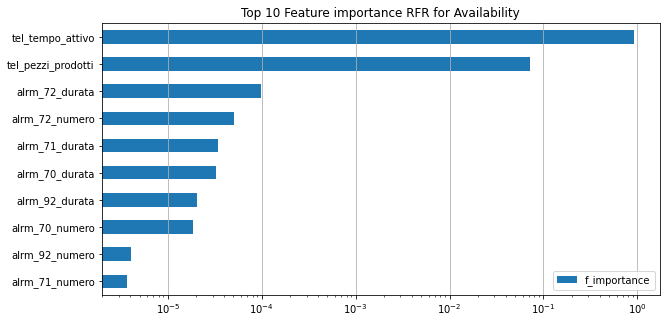

In [119]:
f = plt.figure(figsize=(10, 5))
ax = f.add_subplot()
feats_imp_availab.T.iloc[:10].sort_values('f_importance', ascending=True).plot(kind='barh', ax=ax, logx=True)
_ = ax.grid(axis='x')
_ = ax.set_title('Top 10 Feature importance RFR for Availability')

## Predicting Performance

Our first goal is to predict the performance given the current features. For now we completely forget about the equation we have seen before. 

### MLP

In [126]:
GRIDS_MLP = {
    'hidden_layer_sizes': [(l, n) for l in range(2, 50, 5) for n in range(5, 15)], 
    'learning_rate_init': [0.5*(0.5)**i for i in range(0, 5)], 
    'max_iter': [2000*i for i in range(2, 5)] 
}

In [127]:
gs_mlp_perf = GridSearchCV(MLPRegressor(activation='relu', beta_1=0.95, beta_2=0.75, random_state=90), GRIDS_MLP, 
                      n_jobs=-1, scoring='neg_mean_squared_error', verbose=0, cv=5, )

In [128]:
gs_mlp_perf.fit(X_train_pca5, y_train.efficienza)

GridSearchCV(cv=5,
             estimator=MLPRegressor(beta_1=0.95, beta_2=0.75, random_state=90),
             n_jobs=-1,
             param_grid={'hidden_layer_sizes': [(2, 5), (2, 6), (2, 7), (2, 8),
                                                (2, 9), (2, 10), (2, 11),
                                                (2, 12), (2, 13), (2, 14),
                                                (7, 5), (7, 6), (7, 7), (7, 8),
                                                (7, 9), (7, 10), (7, 11),
                                                (7, 12), (7, 13), (7, 14),
                                                (12, 5), (12, 6), (12, 7),
                                                (12, 8), (12, 9), (12, 10),
                                                (12, 11), (12, 12), (12, 13),
                                                (12, 14), ...],
                         'learning_rate_init': [0.5, 0.25, 0.125, 0.0625,
                                                0.03

In [129]:
pd.DataFrame(gs_mlp_perf.cv_results_) \
    .set_index([f'param_{param}' for param in gs_mlp_perf.param_grid.keys()]) \
    .filter(items=['mean_test_score', 'std_test_score', 'rank_test_score']) \
    .sort_values('rank_test_score', ascending=True).iloc[:5]

mean_test_score  \
param_hidden_layer_sizes param_learning_rate_init param_max_iter                    
(12, 14)                 0.03125                  4000                  -0.008965   
                                                  6000                  -0.008965   
                                                  8000                  -0.008965   
(2, 9)                   0.03125                  8000                  -0.012235   
                                                  6000                  -0.012235   

                                                                  std_test_score  \
param_hidden_layer_sizes param_learning_rate_init param_max_iter                   
(12, 14)                 0.03125                  4000                  0.006935   
                                                  6000                  0.006935   
                                                  8000                  0.006935   
(2, 9)                   0.03125                  8000                  0.009334   
                                                  6000                  0.009334   

                                                                  rank_test_score  
param_hidden_layer_sizes param_learning_rate_init param_max_iter                   
(12, 14)                 0.03125                  4000                          1  
                                                  6000                          1  
                                                  8000                          1  
(2, 9)                   0.03125                  8000                          4  
                                                  6000                          4

In [130]:
pred_y_mlp = gs_mlp_perf.predict(X_test_pca5)

In [131]:
print("R2 Score for MLP: ", r2_score(y_test.efficienza, pred_y_mlp))
print("MAE for MLP: ", mean_absolute_error(y_test.efficienza, pred_y_mlp))
print("MSE for MLP: ", mean_squared_error(y_test.efficienza, pred_y_mlp))

R2 Score for MLP:  -0.4458042742203727
MAE for MLP:  0.0444027643526487
MSE for MLP:  0.004322118344979318


### RFR

In [132]:
GRIDS_RFR = {
    'n_estimators': list(range(10, 100, 10)), 
    'criterion': ['mse', 'mae'], 
    'max_depth': list(range(3, 10)) 
}

In [133]:
gs_rfr_perf = GridSearchCV(RandomForestRegressor(random_state=90), GRIDS_RFR, 
                      n_jobs=-1, scoring='neg_mean_squared_error', verbose=0, cv=5)

In [134]:
gs_rfr_perf.fit(X_train, y_train.efficienza)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=90), n_jobs=-1,
             param_grid={'criterion': ['mse', 'mae'],
                         'max_depth': [3, 4, 5, 6, 7, 8, 9],
                         'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90]},
             scoring='neg_mean_squared_error')

In [135]:
pd.DataFrame(gs_rfr_perf.cv_results_)\
    .set_index([f'param_{param}' for param in gs_rfr_perf.param_grid.keys()]) \
    .filter(items=['mean_test_score', 'std_test_score', 'rank_test_score']) \
    .sort_values('rank_test_score', ascending=True).iloc[:5]

mean_test_score  \
param_n_estimators param_criterion param_max_depth                    
50                 mae             9                      -0.002852   
                   mse             9                      -0.002852   
                   mae             8                      -0.002870   
                   mse             8                      -0.002875   
40                 mae             9                      -0.002877   

                                                    std_test_score  \
param_n_estimators param_criterion param_max_depth                   
50                 mae             9                      0.002101   
                   mse             9                      0.002272   
                   mae             8                      0.002099   
                   mse             8                      0.002279   
40                 mae             9                      0.002101   

                                                    rank_test_score  
param_n_estimators param_criterion param_max_depth                   
50                 mae             9                              1  
                   mse             9                              2  
                   mae             8                              3  
                   mse             8                              4  
40                 mae             9                              5

In [136]:
pred_y_rfr = gs_rfr_perf.predict(X_test)

In [137]:
print("R2 Score for RFR: ", r2_score(y_test.efficienza, pred_y_rfr))
print("MAE for RFR: ", mean_absolute_error(y_test.efficienza, pred_y_rfr))
print("MSE for RFR: ", mean_squared_error(y_test.efficienza, pred_y_rfr))

R2 Score for RFR:  0.39550401878461294
MAE for RFR:  0.03109489743589746
MSE for RFR:  0.0018070932673692342


In [138]:
feats_imp_perf = gs_rfr_perf.best_estimator_.feature_importances_
feats_imp_perf = pd.DataFrame([feats_imp_perf], columns=X_test.columns, index=['f_importance'])

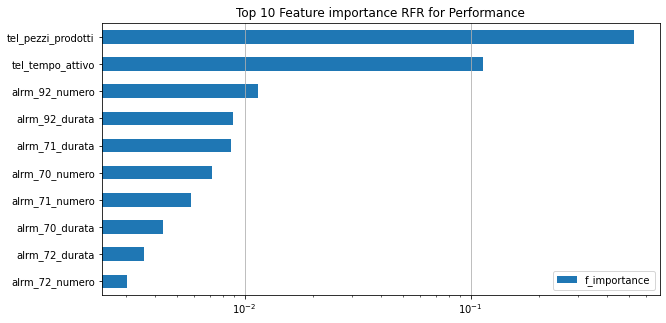

In [139]:
f = plt.figure(figsize=(10, 5))
ax = f.add_subplot()
feats_imp_perf.T.iloc[:10].sort_values('f_importance', ascending=True).plot(kind='barh', ax=ax, logx=True)
_ = ax.grid(axis='x')
_ = ax.set_title('Top 10 Feature importance RFR for Performance')

In [141]:
feats_imp_perf_ = feats_imp_perf.filter(regex='alrm.*').T \
    .rename({'f_importance': 'f_impot_perf'}, axis=1) \
    .sort_index()
feats_imp_avail_ = feats_imp_availab.filter(regex='alrm.*').T \
    .rename({'f_importance': 'f_impot_avail'}, axis=1) \
    .sort_index()

## Comparing alarms feature importance

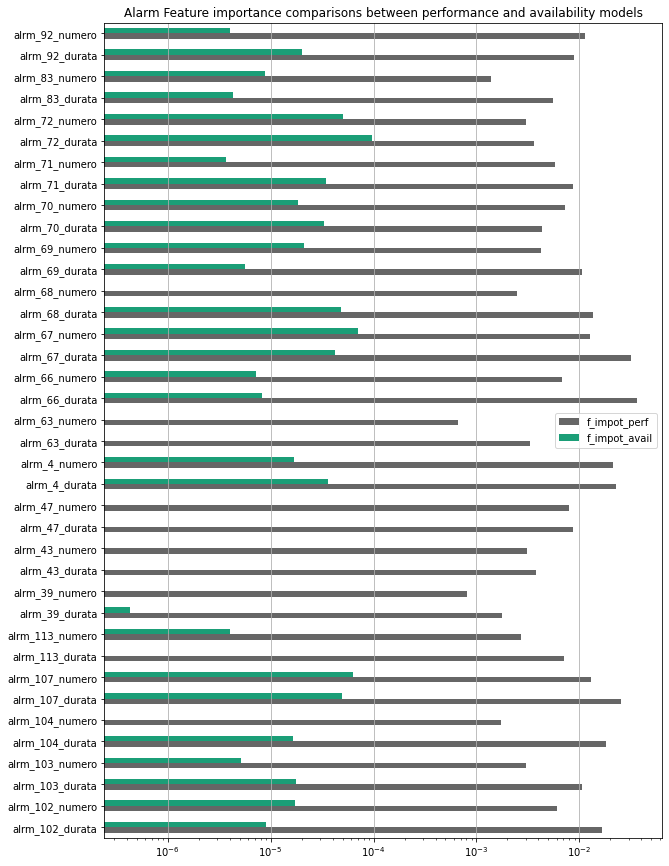

In [142]:
f = plt.figure(figsize=(10, 15))
ax = f.add_subplot()
feats_imp_perf_.join(feats_imp_avail_).plot(kind='barh', logx=True, ax=ax, cmap=plt.cm.Dark2_r)
_ = ax.grid(axis='x')
_ = ax.set_title('Alarm Feature importance comparisons between performance and availability models')

# Using models for predicting Availability and Performance

In [143]:
performance_rf_est = gs_rfr_perf.best_estimator_
performance_mlp_est = gs_mlp_perf.best_estimator_

In [144]:
def dict2array(d): 
    return np.array([[v for v in d.values()]])

In [145]:
def apply_transform(a): 
    return pca_mlp.transform(mm_scaler.transform(a))

In [146]:
test_sample = {k: 0.0 for k in X.columns}

In [147]:
X.tel_pezzi_prodotti.describe()

count     647.000000
mean      855.057839
std       402.366862
min         0.000000
25%       569.311290
50%       917.812485
75%      1181.000461
max      1541.769435
Name: tel_pezzi_prodotti, dtype: float64

In [148]:
test_sample.update({
    'tel_pezzi_prodotti': 0.0, 
    'tel_tempo_attivo': 0.0,
    'alrm_70_durata': 0.0,
    'alrm_70_numero': 0.0,
    'alrm_71_durata': 0.0,
    'alrm_71_numero': 0.0,
    'alrm_92_durata': 0.0,
    'alrm_92_numero': 0.0,
})

In [149]:
performance_rf_est.predict(dict2array(test_sample))

array([0.023714])

In [150]:
performance_mlp_est.predict(apply_transform(dict2array(test_sample)))

array([0.65931434])

# Build Performance Model with only alarms

In [151]:
gs_rfr_perf_v2 = GridSearchCV(RandomForestRegressor(random_state=90), GRIDS_RFR, 
                      n_jobs=-1, scoring='neg_mean_squared_error', verbose=0, cv=5)

In [152]:
gs_rfr_perf_v2.fit(X_train.filter(regex='alrm.*'), y_train.efficienza)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=90), n_jobs=-1,
             param_grid={'criterion': ['mse', 'mae'],
                         'max_depth': [3, 4, 5, 6, 7, 8, 9],
                         'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90]},
             scoring='neg_mean_squared_error')

In [153]:
pd.DataFrame(gs_rfr_perf.cv_results_)\
    .set_index([f'param_{param}' for param in gs_rfr_perf_v2.param_grid.keys()]) \
    .filter(items=['mean_test_score', 'std_test_score', 'rank_test_score']) \
    .sort_values('rank_test_score', ascending=True).iloc[:5]

mean_test_score  \
param_n_estimators param_criterion param_max_depth                    
50                 mae             9                      -0.002852   
                   mse             9                      -0.002852   
                   mae             8                      -0.002870   
                   mse             8                      -0.002875   
40                 mae             9                      -0.002877   

                                                    std_test_score  \
param_n_estimators param_criterion param_max_depth                   
50                 mae             9                      0.002101   
                   mse             9                      0.002272   
                   mae             8                      0.002099   
                   mse             8                      0.002279   
40                 mae             9                      0.002101   

                                                    rank_test_score  
param_n_estimators param_criterion param_max_depth                   
50                 mae             9                              1  
                   mse             9                              2  
                   mae             8                              3  
                   mse             8                              4  
40                 mae             9                              5

In [154]:
pred_y_rfr = gs_rfr_perf_v2.predict(X_test.filter(regex='alrm.*'))

In [155]:
print("R2 Score for RFR: ", r2_score(y_test.efficienza, pred_y_rfr))
print("MAE for RFR: ", mean_absolute_error(y_test.efficienza, pred_y_rfr))
print("MSE for RFR: ", mean_squared_error(y_test.efficienza, pred_y_rfr))

R2 Score for RFR:  -0.2383524345680501
MAE for RFR:  0.04072999145299144
MSE for RFR:  0.0037019573606410293


In [159]:
feats_imp_perf = gs_rfr_perf_v2.best_estimator_.feature_importances_
feats_imp_perf = pd.DataFrame([feats_imp_perf], columns=X_test.filter(regex='alrm.*').columns, 
                              index=['f_importance'])

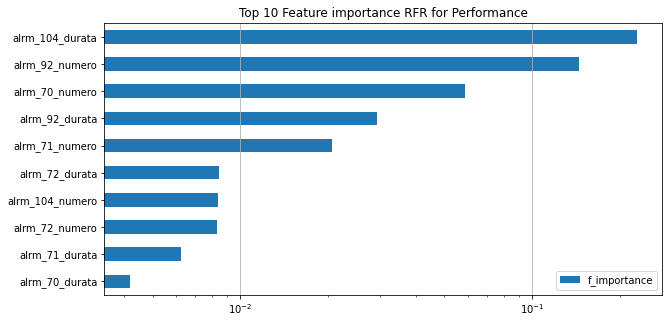

In [160]:
f = plt.figure(figsize=(10, 5))
ax = f.add_subplot()
feats_imp_perf.T.iloc[:10].sort_values('f_importance', ascending=True).plot(kind='barh', ax=ax, logx=True)
_ = ax.grid(axis='x')
_ = ax.set_title('Top 10 Feature importance RFR for Performance')

In [161]:
test_sample = {k: 0.0 for k in X.filter(regex='alrm.*').columns}

In [162]:
test_sample.update({
    'alrm_104_durata': 0.0,
    'alrm_70_numero': 0,
    'alrm_70_durata': 0.0,
    'alrm_71_numero': 0,
    'alrm_71_durata': 0.0,
    'alrm_92_numero': 0,
})

In [163]:
gs_rfr_perf_v2.best_estimator_.predict(dict2array(test_sample))

array([0.94780167])

In [168]:
test_sample.update({
    'alrm_104_durata': 1800.0,
    'alrm_104_numero': 1,
    'alrm_70_numero': 15,
    'alrm_70_durata': 600,
    'alrm_71_numero': 15,
    'alrm_71_durata': 600,
    'alrm_92_numero': 10,
})

In [169]:
gs_rfr_perf_v2.best_estimator_.predict(dict2array(test_sample))

array([0.70550833])